# Phase 1: Data Acquisition, Feature Engineering & K-Means Baseline
**Advanced Market Regime Detection — S&P 500 (2000–2026)**

## 1. Data Acquisition

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Fetch ~26 years of daily S&P 500 OHLCV data
ticker = yf.Ticker('^GSPC')
raw_data = ticker.history(start='2000-01-01', end='2026-04-01')
raw_data.index = raw_data.index.tz_localize(None)  # remove timezone
print(f'Raw data shape: {raw_data.shape}')
raw_data.head()

Raw data shape: (6600, 7)


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2000-01-03,1469.250000,1478.000000,1438.359985,1455.219971,931800000,0.0,0.0
2000-01-04,1455.219971,1455.219971,1397.430054,1399.420044,1009000000,0.0,0.0
2000-01-05,1399.420044,1413.270020,1377.680054,1402.109985,1085500000,0.0,0.0
2000-01-06,1402.109985,1411.900024,1392.099976,1403.449951,1092300000,0.0,0.0
2000-01-07,1403.449951,1441.469971,1400.729980,1441.469971,1225200000,0.0,0.0


In [3]:
# Keep only the columns we need
df = raw_data[['Close', 'High', 'Low', 'Volume']].copy()
print(f'Working dataframe shape: {df.shape}')
df.head()

Working dataframe shape: (6600, 4)


,Close,High,Low,Volume
Date,,,,
2000-01-03,1455.219971,1478.000000,1438.359985,931800000
2000-01-04,1399.420044,1455.219971,1397.430054,1009000000
2000-01-05,1402.109985,1413.270020,1377.680054,1085500000
2000-01-06,1403.449951,1411.900024,1392.099976,1092300000
2000-01-07,1441.469971,1441.469971,1400.729980,1225200000


## 2. The Stationarity Challenge

Raw prices are **non-stationary** — the S&P 500 went from ~1,500 to ~5,000+.  
ML models (especially distance-based ones like K-Means) cannot meaningfully compare prices across different eras.  
We must transform prices into **stationary features**: returns and volatility.

## 3. Feature Engineering

We engineer **3 features** from the raw OHLCV data:

| Feature | Definition |
|---|---|
| **21-Day Rolling Return** | Mean of daily log returns over 21 trading days |
| **21-Day Rolling Volatility** | Std dev of daily log returns over 21 trading days |
| **Volume** | Raw daily trading volume |

**Log Return** (daily):  
$$R_t = \ln\left(\frac{P_t}{P_{t-1}}\right)$$

In [4]:
# --- Step 1: Compute daily log returns ---
df['Log_Return'] = np.log(df['Close'] / df['Close'].shift(1))

# --- Step 2: 21-day rolling return (mean of log returns over 21 days) ---
df['Rolling_Return_21'] = df['Log_Return'].rolling(window=21).mean()

# --- Step 3: 21-day rolling volatility (std of log returns over 21 days) ---
df['Rolling_Volatility_21'] = df['Log_Return'].rolling(window=21).std()

# --- Step 4: Drop NaN rows created by rolling windows ---
print(f'Rows before dropping NaN: {len(df)}')
df.dropna(inplace=True)
print(f'Rows after dropping NaN:  {len(df)}')

df[['Rolling_Return_21', 'Rolling_Volatility_21', 'Volume']].head(10)

Rows before dropping NaN: 6600
Rows after dropping NaN:  6579


,Rolling_Return_21,Rolling_Volatility_21,Volume
Date,,,
2000-02-02,-0.001533,0.016190,1038600000
2000-02-03,0.000862,0.013915,1146500000
2000-02-04,0.000750,0.013915,1045100000
2000-02-07,0.000700,0.013916,918100000
2000-02-08,0.000008,0.012880,1047700000
2000-02-09,-0.001523,0.013394,1050500000
2000-02-10,-0.000725,0.013164,1058800000
2000-02-11,-0.001525,0.013889,1025700000
2000-02-14,-0.002004,0.013565,927300000


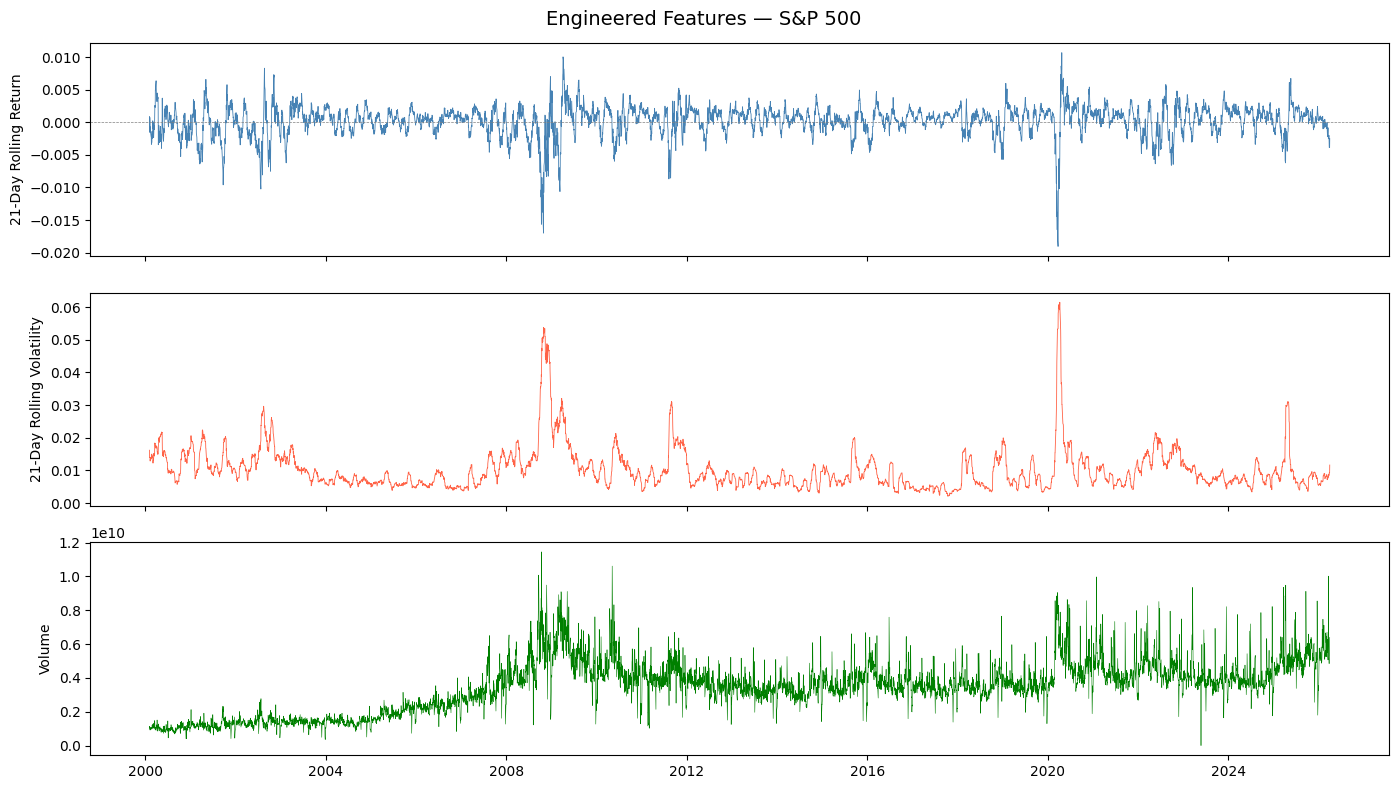

In [5]:
# Quick sanity-check visualization
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

axes[0].plot(df.index, df['Rolling_Return_21'], color='steelblue', linewidth=0.6)
axes[0].set_ylabel('21-Day Rolling Return')
axes[0].axhline(0, color='grey', linestyle='--', linewidth=0.5)

axes[1].plot(df.index, df['Rolling_Volatility_21'], color='tomato', linewidth=0.6)
axes[1].set_ylabel('21-Day Rolling Volatility')

axes[2].plot(df.index, df['Volume'], color='green', linewidth=0.4)
axes[2].set_ylabel('Volume')

fig.suptitle('Engineered Features — S&P 500', fontsize=14)
plt.tight_layout()
plt.show()

## 4. Feature Scaling (StandardScaler)

K-Means is **distance-based** — features on different scales would dominate the clustering.  
Rolling returns are tiny decimals (~0.001), while Volume is in the billions.  
**StandardScaler** (zero mean, unit variance) ensures each feature contributes equally.

In [6]:
# Select the 3 features for clustering
features = ['Rolling_Return_21', 'Rolling_Volatility_21', 'Volume']
X = df[features].values

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Mean after scaling:', X_scaled.mean(axis=0).round(6))
print('Std  after scaling:', X_scaled.std(axis=0).round(6))

Mean after scaling: [0. 0. 0.]
Std  after scaling: [1. 1. 1.]


## 5. Baseline Model — K-Means Clustering

K-Means is our **Track A baseline**:  
- Simple, fast, distance-based  
- Assumes **spherical** clusters (a known limitation for messy financial data)  

We use the **Elbow Method** and **Silhouette Score** to choose *k*.

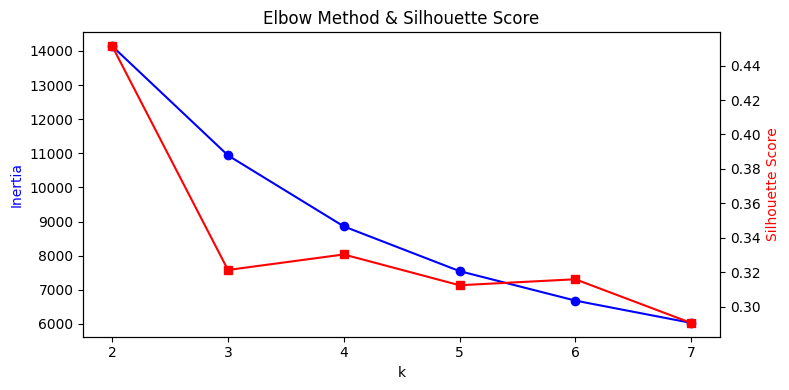

  k=2  Silhouette=0.4513
  k=3  Silhouette=0.3213
  k=4  Silhouette=0.3303
  k=5  Silhouette=0.3124
  k=6  Silhouette=0.3159
  k=7  Silhouette=0.2906


In [7]:
# --- Elbow Method ---
inertias = []
sil_scores = []
K_range = range(2, 8)

for k in K_range:
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(K_range, inertias, 'b-o', label='Inertia')
ax1.set_xlabel('k')
ax1.set_ylabel('Inertia', color='b')

ax2 = ax1.twinx()
ax2.plot(K_range, sil_scores, 'r-s', label='Silhouette')
ax2.set_ylabel('Silhouette Score', color='r')

plt.title('Elbow Method & Silhouette Score')
fig.tight_layout()
plt.show()

for k, s in zip(K_range, sil_scores):
    print(f'  k={k}  Silhouette={s:.4f}')

In [8]:
# --- Fit final K-Means with k=3 (Bull / Bear / Sideways) ---
K = 3
kmeans = KMeans(n_clusters=K, n_init=20, random_state=42)
df['KMeans_Label'] = kmeans.fit_predict(X_scaled)

print(f'Silhouette Score (k={K}): {silhouette_score(X_scaled, df["KMeans_Label"]):.4f}')
print(f'\nCluster value counts:\n{df["KMeans_Label"].value_counts().sort_index()}')

Silhouette Score (k=3): 0.3213

Cluster value counts:
KMeans_Label
0    1891
1     716
2    3972
Name: count, dtype: int64


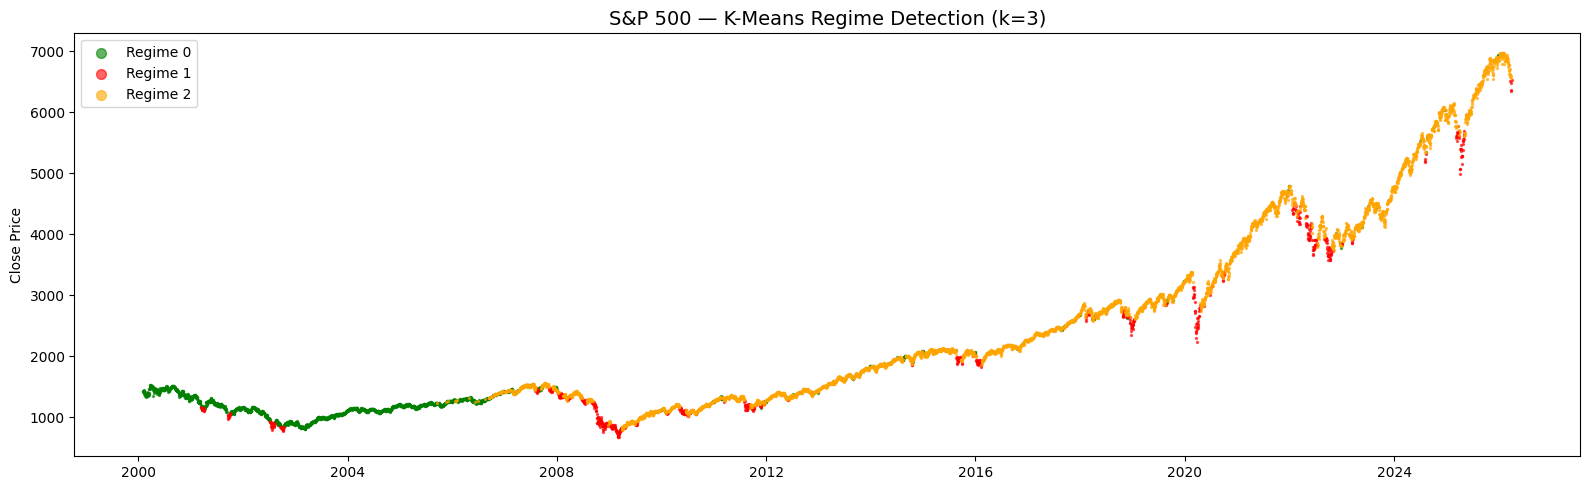

In [9]:
# --- Visualize regimes on the S&P 500 price chart ---
colors = {0: 'green', 1: 'red', 2: 'orange'}
regime_names = {0: 'Regime 0', 1: 'Regime 1', 2: 'Regime 2'}

fig, ax = plt.subplots(figsize=(16, 5))
for regime in sorted(df['KMeans_Label'].unique()):
    mask = df['KMeans_Label'] == regime
    ax.scatter(df.index[mask], df['Close'][mask],
               c=colors[regime], s=2, label=regime_names[regime], alpha=0.6)
ax.set_title('S&P 500 — K-Means Regime Detection (k=3)', fontsize=14)
ax.set_ylabel('Close Price')
ax.legend(markerscale=5)
plt.tight_layout()
plt.show()

In [10]:
# --- Per-regime statistics ---
regime_stats = df.groupby('KMeans_Label')[features].agg(['mean', 'std'])
regime_stats

Rolling_Return_21           Rolling_Volatility_21            \
                          mean       std                  mean       std   
KMeans_Label                                                               
0                     0.000177  0.001858              0.009838  0.004461   
1                    -0.003642  0.002990              0.021440  0.011255   
2                     0.000960  0.001501              0.008491  0.003925   

                    Volume                
                      mean           std  
KMeans_Label                              
0             1.635777e+09  5.744084e+08  
1             5.071255e+09  1.681417e+09  
2             4.017335e+09  8.976756e+08

### Comments

1. No Temporal Awareness
K-Means treats every day independently — it has no concept of "yesterday." So you'll frequently see the labels jump from Bull → Bear → Bull across consecutive days, even when nothing dramatic happened in the market. Real regimes persist for months or years; this choppy switching is unrealistic.

2. Sensitivity to Outliers
Extreme events like the 2008 crisis or COVID crash produce massive outliers that drag cluster centroids away from where they should be, distorting the classification of ordinary days.

3. Fixed k
You must pre-specify the number of regimes. Elbow and Silhouette methods help, but they don't guarantee that k=3 is the economically correct answer.

4. No Transition Probabilities
K-Means cannot tell you how likely it is to stay in Bull tomorrow or how long a Bear regime typically lasts. This is why we later feed the labels into an HMM — it learns realistic transition dynamics and smooths out the noise.

## 6. Export Master Dataset (CSV)

The CSV includes the original data plus all engineered features and K-Means labels,  

In [11]:
# Build the output dataframe
output_cols = ['Close', 'High', 'Low', 'Volume',
               'Log_Return', 'Rolling_Return_21', 'Rolling_Volatility_21',
               'KMeans_Label']
output_df = df[output_cols].copy()

# Also export the scaled features as separate columns (for downstream models)
scaled_df = pd.DataFrame(X_scaled, columns=[f'{f}_scaled' for f in features], index=df.index)
output_df = pd.concat([output_df, scaled_df], axis=1)

# Save
output_df.to_csv('sp500_master_dataset.csv')
print(f'Saved sp500_master_dataset.csv  —  shape: {output_df.shape}')
output_df.head()

Saved sp500_master_dataset.csv  —  shape: (6579, 11)


,Close,High,Low,Volume,Log_Return,Rolling_Return_21,Rolling_Volatility_21,KMeans_Label,Rolling_Return_21_scaled,Rolling_Volatility_21_scaled,Volume_scaled
Date,,,,,,,,,,,
2000-02-02,1409.119995,1420.609985,1403.489990,1038600000,-0.000114,-0.001533,0.016190,0,-0.769203,0.886530,-1.583282
2000-02-03,1424.969971,1425.780029,1398.520020,1146500000,0.011185,0.000862,0.013915,0,0.273191,0.544806,-1.512363
2000-02-04,1424.369995,1435.910034,1420.630005,1045100000,-0.000421,0.000750,0.013915,0,0.224652,0.544877,-1.579010
2000-02-07,1424.239990,1427.150024,1413.329956,918100000,-0.000091,0.000700,0.013916,0,0.202958,0.545042,-1.662482
2000-02-08,1441.719971,1441.829956,1424.239990,1047700000,0.012198,0.000008,0.012880,0,-0.098277,0.389391,-1.577301


---
**Summary — Phase 1 Deliverables:**
1. ✅ Data acquired via `yfinance` (~6,500 rows → ~6,479 after NaN drop)  
2. ✅ Features engineered: 21-day rolling return, 21-day rolling volatility, volume  
3. ✅ StandardScaler applied  
4. ✅ K-Means baseline (k=3) fitted — Silhouette score reported  
5. ✅ Master CSV exported